In [1]:
import Pkg
Pkg.activate("../../../FinancialPlanner")

  Activating project at `c:\Users\matsz\programowanie\Optymalizacja_portfela\FinancialPlanner`


In [2]:
using Revise
using LinearAlgebra
using Distributions
using Random
using StatsPlots
using PDMats
using StatsBase
using Base.Iterators
using DataFrames, TimeSeries, XLSX
using PrettyTables

In [3]:
using Revise

includet("../../src/ESGModels/msvar.jl")
includet("../../src/ESGModels/msvar_gibs.jl")
includet("../../src/ESGModels/msvar_simulate.jl") 
include("../VARs/utils.jl")

calculate_bond_returns

In [85]:
df = DataFrame(XLSX.readtable("../../data/usa_data.xlsx", "Data", infer_eltypes=true))
data_source = collapse(TimeArray(df; timestamp = :Date), Dates.month, last)

freq = 12
#:Price_10Y
returns = percentchange(data_source[:Total_Stock], :log)
cpi = percentchange(data_source[:CPI], :log) 

real_t_bill = log1p.(data_source[:T_Bill])./freq .- cpi

excess_returns = returns .- log1p.(data_source[:T_Bill]./freq)

dy = log.(data_source[:Dividend]) .- log.(data_source[:Stock_Price])

term = data_source[:Yeld_10Y] ./freq .- data_source[:T_Bill] ./freq

#data = merge(excess_returns, real_t_bill, dy, term, log1p.(data_source[:T_Bill]))
data = merge(excess_returns, real_t_bill, term)

start = Date(1985, 01,01)
end_d = Date(2024, 12, 31)
s_data = to(from(data, start),end_d)

display(returns_summarystats(s_data, freq)) 
display(cor(values(s_data)))

,std,max,mean,p75th,min,skewness,p25th,autocor,kurtosis,sr,median
Total_Stock_T_Bill,0.1536,1.458,0.0785,0.4179,-2.9619,-0.9571,-0.2002,0.0138,2.9215,0.5107,0.1321
T_Bill_CPI,0.0126,0.2387,0.0034,0.0303,-0.1559,-0.0771,-0.0226,0.5882,2.2886,0.2675,0.0098
Yeld_10Y_T_Bill,0.0035,0.0394,0.0163,0.0262,-0.015,-0.2687,0.0074,0.9614,-0.6079,4.6663,0.0163


nothing

3×3 Matrix{Float64}:
  1.0        -0.0903778  -0.0483738
 -0.0903778   1.0        -0.143506
 -0.0483738  -0.143506    1.0

In [86]:
assets_names = colnames(s_data)

3-element Vector{Symbol}:
 :Total_Stock_T_Bill
 :T_Bill_CPI
 :Yeld_10Y_T_Bill

In [ ]:
Y, X = prepare_var_data(values(s_data), p=1, X = Matrix{Float64}(undef, 0, 0), add_intercept = true)

([0.005210776914104084 0.0028550106490825384 0.003033333333333333; -0.006399572897336269 0.002125450693431407 0.002608333333333335; … ; 0.030786207595812742 0.004087424285638979 -0.0007333333333333337; 0.008007174130421721 0.0041400960802971095 -0.0009250000000000009], [1.0 0.06830780222021252 0.001499887646889097 0.002841666666666667; 1.0 0.005210776914104084 0.0028550106490825384 0.003033333333333333; … ; 1.0 0.04362223443801919 0.00392657537072938 -0.000616666666666666; 1.0 0.030786207595812742 0.004087424285638979 -0.0007333333333333337])

In [88]:
n_burn = 50_000
n_sample = 2000
n = 2
T = size(Y,1)
Β0 = (inv(transpose(X) * X) * transpose(X) * Y)
Σ0 = transpose((Y -  X * Β0)) * (Y -  X * Β0) / (T- n -1)

tm0 = [.9 .1; .1 .9]

regimes, t_m, Β_post, Σ_post = msvar(Y, X, tm0 , [Β0', Β0'], [Σ0, Σ0], n_burn, n_sample)

([2 2 … 2 2; 2 2 … 2 2; … ; 2 2 … 2 2; 2 2 … 2 2], [0.7657699265010207 0.06524650820653721; 0.7712166199596062 0.0644410245898807; … ; 0.7892756036924954 0.12509702499923686; 0.7300149647432478 0.0815356797194915;;; 0.23423007349897915 0.9347534917934627; 0.2287833800403938 0.9355589754101192; … ; 0.2107243963075046 0.8749029750007631; 0.26998503525675216 0.9184643202805085], Vector{Any}[[[-0.001820064124512251 0.08028907796083554 1.7262743283802768 -29.394208766180316; -0.0008376471180044331 -0.01908377305798026 0.3309858930332167 0.4634572151281015; 0.00014660460467010294 0.00044630798834582777 -0.017578853461880456 0.9514005779871326], [0.025584878450022514 -0.20921485640035759 -0.2000206208937136 -4.2227937751357; 0.00039666946196171925 1.904196486421318e-5 0.5429387043843499 -0.30043185887244195; -8.771107701272154e-7 0.0008177679434732092 -0.007725933843018312 0.9910570324496131]], [[-0.03177518583101235 0.03202862083518248 0.8849756041443051 5.895289737689017; -0.000887902989104

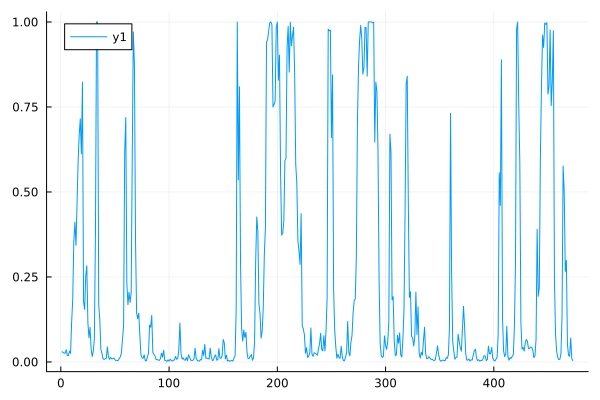

In [89]:
r1 = [count(x -> x ==1, regimes[:,t]) for t in 1:T-1] / n_sample

plot(r1)

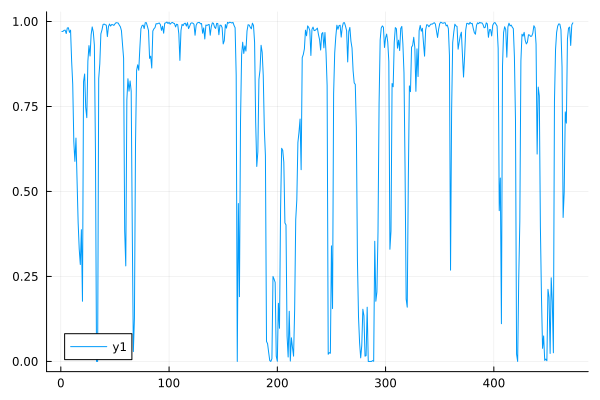

In [90]:
r2 = [count(x -> x ==2, regimes[:,t]) for t in 1:T-1] / n_sample

plot(r2)

In [ ]:
transition_matrix = mean(t_m, dims=1)[1,:,:]
B1 = mean(map(x -> x[1],Β_post))
B2 = mean(map(x -> x[1],Β_post))

cov1_mean = mean(map(x -> x[1], Σ_post))
cov2_mean = mean(map(x -> x[2], Σ_post))




3×3 Matrix{Float64}:
  0.00465261  -6.16321e-5  8.38714e-7
 -6.16321e-5   2.1243e-5   1.73278e-7
  8.38714e-7   1.73278e-7  1.20564e-7

In [77]:
n_steps = 300
n_scenarios = 2000
states_zero = [0.1, 0.9]
scenarios_regimes = simulate_regimes(states_zero, transition_matrix, n_steps, n_scenarios)
scenarios_returns = simulate_msvar_returns(scenarios_regimes, [B1, B2], [cov1_mean, cov2_mean], X[end,2:4], n_steps, 2000)

3×300×2000 Array{Float64, 3}:
[:, :, 1] =
 -0.0703332    -0.0323818     0.110693     …  -0.0743721   0.0116979
  0.00702848    0.00629706    0.00475263       0.00448485  0.000586132
 -0.000673266  -0.000386245  -0.000560425      0.0022299   0.0019326

[:, :, 2] =
  0.0197834    -0.00103926    0.042257     …   0.0233796    -0.0580193
  0.00339875    0.00353687    0.00549626       0.000762536  -0.00399115
 -0.000574662  -0.000408607  -0.000570426     -0.000463524  -0.00074466

[:, :, 3] =
  0.0627381    -0.0514021    -0.0778869    …  0.0440683   0.0969801
  0.00669044    0.00634313    0.00661027      0.00595839  0.00571202
 -0.000693452  -0.000577938  -0.000128129     5.71758e-5  1.7372e-6

;;; … 

[:, :, 1998] =
 -0.081254     0.0958882     0.0169342   …  -0.00264637   0.109877
  0.0114509    0.0106407     0.00924544      0.00420339   0.00219882
 -0.00102628  -0.000982769  -0.00098802     -0.00123075  -0.000284433

[:, :, 1999] =
 -0.0104643    0.0870078   -0.0214369   …  -0.0600384    

In [79]:
periods = [1,5,10,25]
real_returns = scenarios_returns[1, :,:] + scenarios_returns[2, :,:]
ret_on_years = cumsum(real_returns, dims=1)[freq * periods, :] ./ periods

quantile(ret_on_years[1,:], [.05, .25, .5, .75, .95])'


1×5 adjoint(::Vector{Float64}) with eltype Float64:
 -0.010239  0.131653  0.220851  0.309745  0.450995

In [71]:
periods = [1,5, 10, 25]
ret_in_years = cum_returns_in_periods(scenarios_returns, periods, freq, true)
print_scenarios_summary(ret_in_years, assets_names, string.(periods))
n_assets = length(assets_names)
for a in 1:n_assets
    print_scenarios_percentiles(ret_in_years[a, :, :], [.05, .25, .5, .75, .95], string.(periods), string.(assets_names[a]))
end  

,Total_Stock_T_Bill,T_Bill_CPI,Yeld_10Y_T_Bill
1,0.1968,0.0202,-0.0078
5,0.193,0.0147,-0.0038
10,0.1884,0.0128,-0.0007
25,0.1834,0.0112,0.0025


,Total_Stock_T_Bill,T_Bill_CPI,Yeld_10Y_T_Bill
1,0.1314,0.0251,0.0062
5,0.0577,0.0134,0.0096
10,0.0412,0.0102,0.0098
25,0.0268,0.007,0.0082


,Total_Stock_T_Bill,T_Bill_CPI,Yeld_10Y_T_Bill
1,-0.0052,0.0506,-0.0394
5,-0.0726,0.0821,-0.0962
10,-0.1199,0.1035,-0.0653
25,-0.0912,-0.0796,0.031


,Total_Stock_T_Bill,T_Bill_CPI,Yeld_10Y_T_Bill
1,1.0819,0.5637,0.5086
5,0.1422,0.1918,0.2302
10,0.2215,0.119,0.1542
25,0.1517,0.056,0.0282


,0.05,0.25,0.5,0.75,0.95
1,-0.0149,0.1148,0.198,0.2782,0.4127
5,0.1009,0.1555,0.1938,0.2309,0.2884
10,0.122,0.161,0.1888,0.2165,0.2553
25,0.1373,0.1659,0.1833,0.2019,0.2271


,0.05,0.25,0.5,0.75,0.95
1,-0.0216,0.0041,0.0203,0.0358,0.0615
5,-0.0067,0.0059,0.0144,0.0235,0.0365
10,-0.0031,0.006,0.0127,0.0194,0.0304
25,-0.0006,0.0065,0.0113,0.0159,0.0225


,0.05,0.25,0.5,0.75,0.95
1,-0.0179,-0.0117,-0.008,-0.0037,0.0026
5,-0.0198,-0.01,-0.0036,0.0027,0.0118
10,-0.0174,-0.0071,-0.0008,0.006,0.0149
25,-0.0107,-0.0031,0.0026,0.0079,0.0156


###TODO

- plot regimes probs with dates
- tranfrom posterior mean, to model
- print model summary from means